# Conformal prediction for five-minute-ahead MCP

This notebook turns the LightGBM point forecast from `02_baseline_models.ipynb` into
**prediction intervals** and a **predictive distribution**.

The forecast task is fixed first, then every feature is lagged so it would have been
known at the forecast origin. A chronological train / calibration / test split is used
so that:

- the point model is fit on **train** only
- conformal scores are computed on **calibration** only
- **test** is used once, for evaluation

Three conformal constructions are compared:

1. **Split conformal** (absolute residuals) — constant-width intervals, finite-sample coverage under exchangeability
2. **Normalized split conformal** — same guarantee, widths scale with a residual-magnitude model
3. **Conformalized quantile regression (CQR)** — LightGBM quantile forecasts, then conformal correction

A **residual conformal predictive system (CPS)** is also built from the signed calibration residuals so that pinball loss and CRPS can be scored on a full predictive distribution.

Use the **MATH5001** kernel. Fitting the point model, the residual-scale model, and six quantile models takes a few minutes.


## Forecast contract

**Target.** $Y_t = \mathrm{MCP}_t$ (market clearing price, AUD/MWh).

**Origin.** The end of the previous five-minute dispatch interval, $t-5$.

**Information set.** Only data that would already have been published by the origin:
lagged MCP, lagged operational / STEM / RTP / FCAS quantities, and deterministic calendar features. Same-interval demand, DPV, SCADA, STEM, RTP, and FCAS are **not** used.

**Output.** For nominal coverages $1-\alpha \in \{0.50, 0.80, 0.90, 0.95\}$, a prediction interval $\hat C_t$ and, from the CPS, a predictive CDF $\hat F_t$.

Standard split conformal gives the marginal guarantee
$P(Y_t \in \hat C_t) \ge 1-\alpha$ if the calibration and test pairs are exchangeable. Electricity prices are a time series, so that assumption is approximate. Coverage is therefore reported overall, by month, and by hour of day.


## Methods

Let $\hat y(x)$ be a point forecast trained on the training block.

**Split conformal.** Conformity scores on the calibration block are $s_i = |y_i - \hat y(x_i)|$. The finite-sample quantile
$$
\hat q_{1-\alpha} = s_{(\lceil (n+1)(1-\alpha)\rceil)},
$$
with $s_{(k)}$ the $k$-th order statistic (clipped to the maximum if the index exceeds $n$), gives the interval $[\hat y(x) - \hat q_{1-\alpha},\, \hat y(x) + \hat q_{1-\alpha}]$.

**Normalized split conformal.** A second LightGBM is trained on training absolute residuals to estimate a scale $\hat\sigma(x)$. Scores $s_i = |y_i - \hat y(x_i)| / \max(\hat\sigma(x_i),\varepsilon)$ produce intervals whose width tracks local volatility.

**CQR (Romano, Patterson, Candès).** Quantile LightGBMs $\hat q_{\alpha/2}(x)$ and $\hat q_{1-\alpha/2}(x)$ are trained on the training block. Calibration scores
$s_i = \max\{\hat q_{\alpha/2}(x_i) - y_i,\, y_i - \hat q_{1-\alpha/2}(x_i)\}$
are conformalized in the same way. The resulting interval can be narrower or wider than the raw quantile interval; $\hat q$ may be negative.

**Residual CPS.** Let $R_i = y_i - \hat y(x_i)$ on calibration. The predictive CDF at a new $x$ is the empirical distribution of $\{\hat y(x) + R_i\}_{i=1}^n$, with the usual $+1$ conformal correction in the quantile index. This is a first CPS benchmark, not the full Vovk–Gammerman kernel CPS.


In [1]:
from pathlib import Path
import sys
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore", category=UserWarning)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.paths import panel_path

PANEL_PATH = panel_path()
RESULTS_DIR = PROJECT_ROOT / "reports" / "forecasting"
FIGURE_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COVERAGE_LEVELS = [0.50, 0.80, 0.90, 0.95]
LGBM_PARAMS = dict(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=100,
    max_depth=5,
    min_child_samples=50,
    subsample=0.9,
    subsample_freq=1,
    colsample_bytree=0.6,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1,
)

print(f"Panel: {PANEL_PATH.as_posix()}")
print(f"Results: {RESULTS_DIR.as_posix()}")


Panel: /app/data/processed/wem_5min_panel.parquet
Results: /app/reports/forecasting


In [2]:
raw = pd.read_parquet(PANEL_PATH, engine="pyarrow")
raw["interval_end"] = pd.to_datetime(raw["interval_end"])
raw = raw.sort_values("interval_end").drop_duplicates("interval_end", keep="last")
raw = raw.set_index("interval_end")

full_index = pd.date_range(raw.index.min(), raw.index.max(), freq="5min", name="interval_end")
panel = raw.reindex(full_index)
panel.index.name = "interval_end"

print(f"Raw rows: {len(raw):,}")
print(f"Complete 5-minute grid: {len(panel):,}")
print(f"Range: {panel.index.min()} → {panel.index.max()}")
print(f"Missing MCP on the grid: {panel['mcp'].isna().mean():.4%}")
panel[["mcp"]].head()


Raw rows: 302,964
Complete 5-minute grid: 302,976
Range: 2023-10-01 08:00:00 → 2026-08-18 07:55:00
Missing MCP on the grid: 0.0040%


,mcp
interval_end,
2023-10-01 08:00:00,738.00
2023-10-01 08:05:00,738.00
2023-10-01 08:10:00,738.00
2023-10-01 08:15:00,738.00
2023-10-01 08:20:00,263.54


## Leakage-safe features

Lags are built **after** reindexing onto the complete five-minute grid, so a lag at timestamp $t$ is the value exactly 5, 30, or 60 minutes earlier (or missing if that interval was absent).

Contemporaneous operational, STEM, RTP, and FCAS columns are shifted by one interval. Calendar features are known at the origin. `year` is dropped because it cannot generalise across the 2023–2026 regime shift seen in notebook 02.


In [3]:
DROP_UNUSED = [
    "rocof",
    "minute",
    "dpv_mw_30min",
    "sent_out_mwh",
    "sent_out_mw",
    "scada_mwh",
    "unscheduled_demand_mw",
    "scheduled_energy_mw",
    "trading_interval_end",
    "is_weekend",
    "year",
    "mcp_lag1",
    "mcp_lag6",
    "mcp_lag12",
]
panel = panel.drop(columns=[c for c in DROP_UNUSED if c in panel.columns])

# MCP lags: 1, 6, 12 five-minute steps.
panel["mcp_lag_5m"] = panel["mcp"].shift(1)
panel["mcp_lag_30m"] = panel["mcp"].shift(6)
panel["mcp_lag_60m"] = panel["mcp"].shift(12)

CONTEMPORANEOUS = [
    "operational_demand_mw",
    "operational_withdrawal_mw",
    "dpv_mw",
    "stem_price",
    "stem_qty_mwh",
    "stem_bid_mwh",
    "stem_offer_mwh",
    "scada_mw",
    "residual_demand_mw",
    "rtp",
    "cr_raise",
    "cr_lower",
    "reg_raise",
    "reg_lower",
]
for col in CONTEMPORANEOUS:
    if col not in panel.columns:
        raise KeyError(f"Expected column missing from panel: {col}")
    panel[f"{col}_lag1"] = panel[col].shift(1)

minutes = panel.index.hour * 60 + panel.index.minute
panel["sin_time_of_day"] = np.sin(2 * np.pi * minutes / 1440)
panel["cos_time_of_day"] = np.cos(2 * np.pi * minutes / 1440)
panel["sin_day_of_week"] = np.sin(2 * np.pi * panel.index.dayofweek / 7)
panel["cos_day_of_week"] = np.cos(2 * np.pi * panel.index.dayofweek / 7)
panel["sin_month"] = np.sin(2 * np.pi * panel.index.month / 12)
panel["cos_month"] = np.cos(2 * np.pi * panel.index.month / 12)

TARGET = "mcp"
FEATURES = [
    "mcp_lag_5m",
    "mcp_lag_30m",
    "mcp_lag_60m",
    *[f"{c}_lag1" for c in CONTEMPORANEOUS],
    "sin_time_of_day",
    "cos_time_of_day",
    "sin_day_of_week",
    "cos_day_of_week",
    "sin_month",
    "cos_month",
]

model_data = panel[[TARGET, *FEATURES]].dropna().copy()
print(f"Model rows after lag/NA drop: {len(model_data):,}")
print(f"Features ({len(FEATURES)}): {FEATURES}")
model_data.head()


Model rows after lag/NA drop: 302,913
Features (23): ['mcp_lag_5m', 'mcp_lag_30m', 'mcp_lag_60m', 'operational_demand_mw_lag1', 'operational_withdrawal_mw_lag1', 'dpv_mw_lag1', 'stem_price_lag1', 'stem_qty_mwh_lag1', 'stem_bid_mwh_lag1', 'stem_offer_mwh_lag1', 'scada_mw_lag1', 'residual_demand_mw_lag1', 'rtp_lag1', 'cr_raise_lag1', 'cr_lower_lag1', 'reg_raise_lag1', 'reg_lower_lag1', 'sin_time_of_day', 'cos_time_of_day', 'sin_day_of_week', 'cos_day_of_week', 'sin_month', 'cos_month']


,mcp,mcp_lag_5m,mcp_lag_30m,mcp_lag_60m,operational_demand_mw_lag1,operational_withdrawal_mw_lag1,dpv_mw_lag1,stem_price_lag1,stem_qty_mwh_lag1,stem_bid_mwh_lag1,...,cr_raise_lag1,cr_lower_lag1,reg_raise_lag1,reg_lower_lag1,sin_time_of_day,cos_time_of_day,sin_day_of_week,cos_day_of_week,sin_month,cos_month
interval_end,,,,,,,,,,,,,,,,,,,,,
2023-10-01 09:00:00,165.17,98.47,161.42,738.00,1421.85,-6.45,776.66,65.13,80.879,562.504,...,25.99,33.86,12.67,34.52,0.707107,-0.707107,-0.781831,0.62349,-0.866025,0.5
2023-10-01 09:05:00,184.17,165.17,107.13,738.00,1454.06,-7.13,784.86,65.13,80.879,562.504,...,91.99,10.02,50.16,10.21,0.691513,-0.722364,-0.781831,0.62349,-0.866025,0.5
2023-10-01 09:10:00,184.22,184.17,73.23,738.00,1449.33,-6.88,768.18,65.10,49.410,514.018,...,110.99,10.02,60.05,10.61,0.675590,-0.737277,-0.781831,0.62349,-0.866025,0.5
2023-10-01 09:15:00,109.38,184.22,73.45,738.00,1451.53,-6.19,802.18,65.10,49.410,514.018,...,111.15,10.02,60.13,10.61,0.659346,-0.751840,-0.781831,0.62349,-0.866025,0.5
2023-10-01 09:20:00,99.96,109.38,98.55,263.54,1405.64,-6.97,825.22,65.10,49.410,514.018,...,0.22,10.95,0.22,11.16,0.642788,-0.766044,-0.781831,0.62349,-0.866025,0.5


In [4]:
assert model_data.index.is_unique
assert model_data.index.is_monotonic_increasing
assert pd.infer_freq(panel.index) == "5min"
assert (panel.index.to_series().diff().dropna() == pd.Timedelta(minutes=5)).all()

check_time = model_data.index[12]
assert panel.loc[check_time, "mcp_lag_5m"] == panel.loc[check_time - pd.Timedelta(minutes=5), "mcp"]
assert panel.loc[check_time, "mcp_lag_30m"] == panel.loc[check_time - pd.Timedelta(minutes=30), "mcp"]
assert panel.loc[check_time, "mcp_lag_60m"] == panel.loc[check_time - pd.Timedelta(minutes=60), "mcp"]
assert panel.loc[check_time, "operational_demand_mw_lag1"] == panel.loc[
    check_time - pd.Timedelta(minutes=5), "operational_demand_mw"
]
print("time-grid and lag checks passed")


time-grid and lag checks passed


## Chronological split

Contiguous 70 / 15 / 15 blocks. The test block is not used for fitting, calibration, or model selection. Dates are printed so they can be frozen in the thesis methodology.


In [5]:
n = len(model_data)
train_end = model_data.index[int(n * 0.70) - 1]
calibration_end = model_data.index[int(n * 0.85) - 1]

train = model_data.loc[model_data.index <= train_end]
calibration = model_data.loc[(model_data.index > train_end) & (model_data.index <= calibration_end)]
test = model_data.loc[model_data.index > calibration_end]

assert train.index.max() < calibration.index.min()
assert calibration.index.max() < test.index.min()

X_train, y_train = train[FEATURES], train[TARGET]
X_cal, y_cal = calibration[FEATURES], calibration[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

split_summary = pd.DataFrame(
    {
        "start": [train.index.min(), calibration.index.min(), test.index.min()],
        "end": [train.index.max(), calibration.index.max(), test.index.max()],
        "n": [len(train), len(calibration), len(test)],
    },
    index=["train", "calibration", "test"],
)
display(split_summary)


,start,end,n
train,2023-10-01 09:00:00,2025-10-06 17:25:00,212039
calibration,2025-10-06 17:30:00,2026-03-13 13:05:00,45437
test,2026-03-13 13:10:00,2026-08-18 07:35:00,45437


## Point forecast

LightGBM uses the hyperparameters selected in notebook 02. Persistence (last 5-minute MCP) is the operational baseline; notebook 02 showed it is competitive on MAE.


In [6]:
point_model = lgb.LGBMRegressor(**LGBM_PARAMS)
point_model.fit(X_train, y_train)

predictions = pd.DataFrame(index=test.index)
predictions["actual"] = y_test.to_numpy()
predictions["persistence_5m"] = test["mcp_lag_5m"].to_numpy()
predictions["lightgbm"] = point_model.predict(X_test)

yhat_cal = point_model.predict(X_cal)
resid_cal = y_cal.to_numpy() - yhat_cal
abs_resid_cal = np.abs(resid_cal)

point_rows = []
for name in ["persistence_5m", "lightgbm"]:
    point_rows.append(
        {
            "model": name,
            "MAE": mean_absolute_error(predictions["actual"], predictions[name]),
            "RMSE": mean_squared_error(predictions["actual"], predictions[name]) ** 0.5,
        }
    )
point_results = pd.DataFrame(point_rows).set_index("model")
display(point_results.round(4))
print(f"Calibration |residual| median: {np.median(abs_resid_cal):.3f}")
print(f"Calibration |residual| p90:    {np.quantile(abs_resid_cal, 0.90):.3f}")


,MAE,RMSE
model,,
persistence_5m,4.6229,16.5355
lightgbm,6.1119,15.7381


Calibration |residual| median: 3.441
Calibration |residual| p90:    14.145


## Conformal helpers

`conformal_quantile` is the finite-sample split-conformal order statistic. Interval scores are empirical coverage, mean width, and the Winkler (interval) score.


In [7]:
def conformal_quantile(scores: np.ndarray, coverage: float) -> float:
    """Finite-sample split-conformal quantile of conformity scores."""
    scores = np.asarray(scores, dtype=float)
    if scores.size == 0:
        raise ValueError("calibration scores cannot be empty")
    rank = int(np.ceil((len(scores) + 1) * coverage))
    rank = min(max(rank, 1), len(scores))
    return float(np.sort(scores)[rank - 1])


def interval_metrics(actual: np.ndarray, lower: np.ndarray, upper: np.ndarray, coverage: float) -> dict:
    inside = (actual >= lower) & (actual <= upper)
    width = upper - lower
    alpha = 1.0 - coverage
    winkler = width.copy()
    below = actual < lower
    above = actual > upper
    winkler[below] = width[below] + (2.0 / alpha) * (lower[below] - actual[below])
    winkler[above] = width[above] + (2.0 / alpha) * (actual[above] - upper[above])
    return {
        "empirical_coverage": float(inside.mean()),
        "mean_width": float(width.mean()),
        "median_width": float(np.median(width)),
        "mean_winkler": float(winkler.mean()),
    }


def pinball(actual: np.ndarray, quantile: np.ndarray, tau: float) -> float:
    delta = actual - quantile
    return float(np.mean(np.where(delta >= 0, tau * delta, (tau - 1.0) * delta)))


def crps_residual_cps(test_residuals: np.ndarray, cal_residuals: np.ndarray) -> np.ndarray:
    """CRPS of the empirical residual CPS, one value per test residual.

    Predictive samples are {ŷ + R_i}. CRPS depends only on r = y - ŷ and the
    calibration residuals. Pairwise term uses the sorted-sum identity.
    """
    s = np.sort(np.asarray(cal_residuals, dtype=float))
    n = len(s)
    i = np.arange(1, n + 1)
    pairwise = (2.0 / n**2) * np.dot(2 * i - n - 1, s)
    r = np.asarray(test_residuals, dtype=float)
    k = np.searchsorted(s, r, side="left")
    csum = np.concatenate([[0.0], np.cumsum(s)])
    term1 = (2.0 * r * k - 2.0 * csum[k] + csum[n] - n * r) / n
    return term1 - 0.5 * pairwise


## Split conformal intervals

Absolute-residual split conformal produces one radius per coverage level, shared by every test origin. Normalized split conformal divides by a LightGBM scale model fit on training absolute residuals, so intervals widen when the model expects a spike.


In [8]:
# --- symmetric split conformal ---
for coverage in COVERAGE_LEVELS:
    radius = conformal_quantile(abs_resid_cal, coverage)
    suffix = int(coverage * 100)
    predictions[f"split_lower_{suffix}"] = predictions["lightgbm"] - radius
    predictions[f"split_upper_{suffix}"] = predictions["lightgbm"] + radius
    print(f"split {suffix}% radius: {radius:.4f} $/MWh")

# --- normalized split conformal ---
scale_model = lgb.LGBMRegressor(**LGBM_PARAMS)
scale_model.fit(X_train, np.abs(y_train.to_numpy() - point_model.predict(X_train)))
EPS = 1e-3
scale_cal = np.maximum(scale_model.predict(X_cal), EPS)
scale_test = np.maximum(scale_model.predict(X_test), EPS)
norm_scores = abs_resid_cal / scale_cal

for coverage in COVERAGE_LEVELS:
    qhat = conformal_quantile(norm_scores, coverage)
    suffix = int(coverage * 100)
    predictions[f"norm_lower_{suffix}"] = predictions["lightgbm"] - qhat * scale_test
    predictions[f"norm_upper_{suffix}"] = predictions["lightgbm"] + qhat * scale_test
    print(f"normalized {suffix}% q-hat: {qhat:.4f}")


split 50% radius: 3.4411 $/MWh
split 80% radius: 8.6349 $/MWh
split 90% radius: 14.1477 $/MWh
split 95% radius: 21.6118 $/MWh
normalized 50% q-hat: 0.4823
normalized 80% q-hat: 1.0548
normalized 90% q-hat: 1.5607
normalized 95% q-hat: 2.1231


## Conformalized quantile regression

A pair of LightGBM quantile models is trained for each coverage level. Conformity scores on calibration are the amount by which the observed MCP falls outside the raw quantile interval.


In [9]:
def tau_key(t: float) -> float:
    return round(float(t), 6)

quantile_models = {}
cqr_coverages = [0.80, 0.90, 0.95]
needed_taus = []
for coverage in cqr_coverages:
    alpha = 1.0 - coverage
    needed_taus.extend([tau_key(alpha / 2.0), tau_key(1.0 - alpha / 2.0)])
needed_taus = sorted(set(needed_taus))

for tau in needed_taus:
    print(f"fitting quantile LightGBM tau={tau:.4f}")
    q_model = lgb.LGBMRegressor(objective="quantile", alpha=tau, **LGBM_PARAMS)
    q_model.fit(X_train, y_train)
    quantile_models[tau] = q_model

for coverage in cqr_coverages:
    alpha = 1.0 - coverage
    tau_lo, tau_hi = tau_key(alpha / 2.0), tau_key(1.0 - alpha / 2.0)
    q_lo_cal = quantile_models[tau_lo].predict(X_cal)
    q_hi_cal = quantile_models[tau_hi].predict(X_cal)
    cqr_scores = np.maximum(q_lo_cal - y_cal.to_numpy(), y_cal.to_numpy() - q_hi_cal)
    qhat = conformal_quantile(cqr_scores, coverage)
    suffix = int(coverage * 100)
    q_lo_test = quantile_models[tau_lo].predict(X_test)
    q_hi_test = quantile_models[tau_hi].predict(X_test)
    predictions[f"cqr_lower_{suffix}"] = q_lo_test - qhat
    predictions[f"cqr_upper_{suffix}"] = q_hi_test + qhat
    print(f"CQR {suffix}%  tau=({tau_lo:.3f}, {tau_hi:.3f})  q-hat={qhat:.4f}")


fitting quantile LightGBM tau=0.0250
fitting quantile LightGBM tau=0.0500
fitting quantile LightGBM tau=0.1000
fitting quantile LightGBM tau=0.9000
fitting quantile LightGBM tau=0.9500
fitting quantile LightGBM tau=0.9750
CQR 80%  tau=(0.100, 0.900)  q-hat=-1.1893
CQR 90%  tau=(0.050, 0.950)  q-hat=-1.3450
CQR 95%  tau=(0.025, 0.975)  q-hat=-1.6894


## Residual conformal predictive system

The CPS at a test origin is the empirical distribution of the LightGBM point forecast plus the calibration residuals. Quantiles use the same $\lceil(n+1)\tau\rceil$ index as split conformal. CRPS is the closed-form empirical-distribution score of Gneiting and Raftery.


In [10]:
resid_sorted = np.sort(resid_cal)
n_cal = len(resid_sorted)

def cps_quantile(yhat: np.ndarray, tau: float) -> np.ndarray:
    rank = int(np.ceil((n_cal + 1) * tau))
    rank = min(max(rank, 1), n_cal)
    return yhat + resid_sorted[rank - 1]

PINBALL_TAUS = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
cps_quantiles = {tau: cps_quantile(predictions["lightgbm"].to_numpy(), tau) for tau in PINBALL_TAUS}

test_resid = predictions["actual"].to_numpy() - predictions["lightgbm"].to_numpy()
cps_crps = crps_residual_cps(test_resid, resid_cal)

pinball_rows = [
    {"tau": tau, "pinball": pinball(predictions["actual"].to_numpy(), cps_quantiles[tau], tau)}
    for tau in PINBALL_TAUS
]
pinball_results = pd.DataFrame(pinball_rows)
print(f"Mean CRPS (residual CPS): {cps_crps.mean():.4f} $/MWh")
display(pinball_results.round(4))


Mean CRPS (residual CPS): 4.9944 $/MWh


,tau,pinball
0,0.05,1.3912
1,0.10,1.8953
2,0.25,2.6405
3,0.50,3.0547
4,0.75,2.8132
5,0.90,2.1939
6,0.95,1.7631


## Evaluation


In [11]:
METHODS = {
    "split": "Split conformal",
    "norm": "Normalized split",
    "cqr": "CQR",
}

interval_rows = []
actual = predictions["actual"].to_numpy()
for method, label in METHODS.items():
    coverages = COVERAGE_LEVELS if method != "cqr" else cqr_coverages
    for coverage in coverages:
        suffix = int(coverage * 100)
        lower_col, upper_col = f"{method}_lower_{suffix}", f"{method}_upper_{suffix}"
        if lower_col not in predictions.columns:
            continue
        metrics = interval_metrics(
            actual,
            predictions[lower_col].to_numpy(),
            predictions[upper_col].to_numpy(),
            coverage,
        )
        interval_rows.append(
            {"method": label, "nominal_coverage": coverage, **metrics}
        )

interval_results = pd.DataFrame(interval_rows)
interval_results["coverage_gap"] = (
    interval_results["empirical_coverage"] - interval_results["nominal_coverage"]
)
display(point_results.round(4))
display(interval_results.round(4))

# Monthly coverage for the 90% intervals
monthly_rows = []
for month, frame in predictions.groupby(predictions.index.to_period("M")):
    row = {"month": str(month), "n": len(frame)}
    for method in METHODS:
        col_l, col_u = f"{method}_lower_90", f"{method}_upper_90"
        if col_l not in frame.columns:
            continue
        row[f"{method}_cov90"] = (
            (frame["actual"] >= frame[col_l]) & (frame["actual"] <= frame[col_u])
        ).mean()
        row[f"{method}_width90"] = (frame[col_u] - frame[col_l]).mean()
    monthly_rows.append(row)
monthly_coverage = pd.DataFrame(monthly_rows)
display(monthly_coverage.round(4))


,MAE,RMSE
model,,
persistence_5m,4.6229,16.5355
lightgbm,6.1119,15.7381


,method,nominal_coverage,empirical_coverage,mean_width,median_width,mean_winkler,coverage_gap
0,Split conformal,0.50,0.5601,6.8822,6.8822,21.8194,0.0601
1,Split conformal,0.80,0.8402,17.2698,17.2698,40.8845,0.0402
2,Split conformal,0.90,0.9169,28.2955,28.2955,63.0707,0.0169
3,Split conformal,0.95,0.9498,43.2237,43.2237,93.5829,-0.0002
4,Normalized split,0.50,0.5047,8.4795,6.4215,20.3339,0.0047
5,Normalized split,0.80,0.8070,18.5448,14.0439,32.0747,0.0070
6,Normalized split,0.90,0.9042,27.4380,20.7786,42.8006,0.0042
7,Normalized split,0.95,0.9513,37.3253,28.2662,54.6112,0.0013
8,CQR,0.80,0.8109,23.3779,14.3681,34.0430,0.0109
9,CQR,0.90,0.9189,41.2037,24.4132,50.6604,0.0189


,month,n,split_cov90,split_width90,norm_cov90,norm_width90,cqr_cov90,cqr_width90
0,2026-03,5314,0.9688,28.2955,0.9324,22.7410,0.9562,30.9270
1,2026-04,8640,0.9747,28.2955,0.8801,18.2544,0.8838,22.7689
2,2026-05,8928,0.8987,28.2955,0.8566,27.0390,0.8714,35.9377
3,2026-06,8640,0.8723,28.2955,0.9262,34.5950,0.9539,64.2394
4,2026-07,8927,0.8948,28.2955,0.9327,32.7705,0.9417,50.0481
5,2026-08,4988,0.9106,28.2955,0.9124,27.1227,0.9230,37.7794


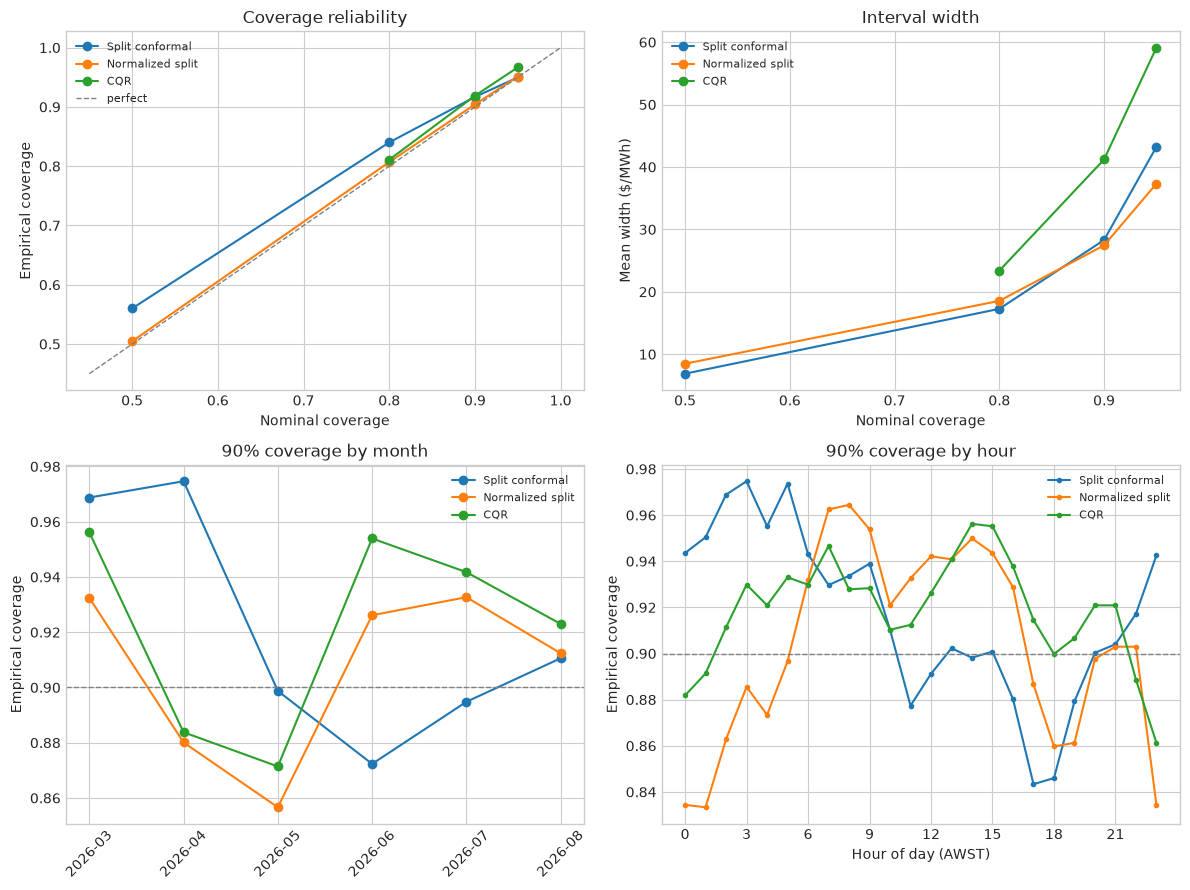

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Reliability: empirical vs nominal coverage
ax = axes[0, 0]
for method, label in METHODS.items():
    sub = interval_results[interval_results["method"] == label]
    ax.plot(sub["nominal_coverage"], sub["empirical_coverage"], marker="o", label=label)
ax.plot([0.45, 1.0], [0.45, 1.0], ls="--", color="grey", lw=1, label="perfect")
ax.set_xlabel("Nominal coverage")
ax.set_ylabel("Empirical coverage")
ax.set_title("Coverage reliability")
ax.legend(fontsize=8)

# 2. Mean width vs coverage
ax = axes[0, 1]
for method, label in METHODS.items():
    sub = interval_results[interval_results["method"] == label]
    ax.plot(sub["nominal_coverage"], sub["mean_width"], marker="o", label=label)
ax.set_xlabel("Nominal coverage")
ax.set_ylabel("Mean width ($/MWh)")
ax.set_title("Interval width")
ax.legend(fontsize=8)

# 3. Monthly 90% coverage
ax = axes[1, 0]
for method, label in METHODS.items():
    col = f"{method}_cov90"
    if col in monthly_coverage.columns:
        ax.plot(monthly_coverage["month"], monthly_coverage[col], marker="o", label=label)
ax.axhline(0.90, ls="--", color="grey", lw=1)
ax.set_ylabel("Empirical coverage")
ax.set_title("90% coverage by month")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)

# 4. Hour-of-day 90% coverage (split vs normalized vs CQR)
ax = axes[1, 1]
hours = predictions.index.hour
for method, label in METHODS.items():
    col_l, col_u = f"{method}_lower_90", f"{method}_upper_90"
    if col_l not in predictions.columns:
        continue
    cov = (
        (predictions["actual"] >= predictions[col_l])
        & (predictions["actual"] <= predictions[col_u])
    ).groupby(hours).mean()
    ax.plot(cov.index, cov.values, marker="o", ms=3, label=label)
ax.axhline(0.90, ls="--", color="grey", lw=1)
ax.set_xlabel("Hour of day (AWST)")
ax.set_ylabel("Empirical coverage")
ax.set_title("90% coverage by hour")
ax.set_xticks(range(0, 24, 3))
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "cps_coverage_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()


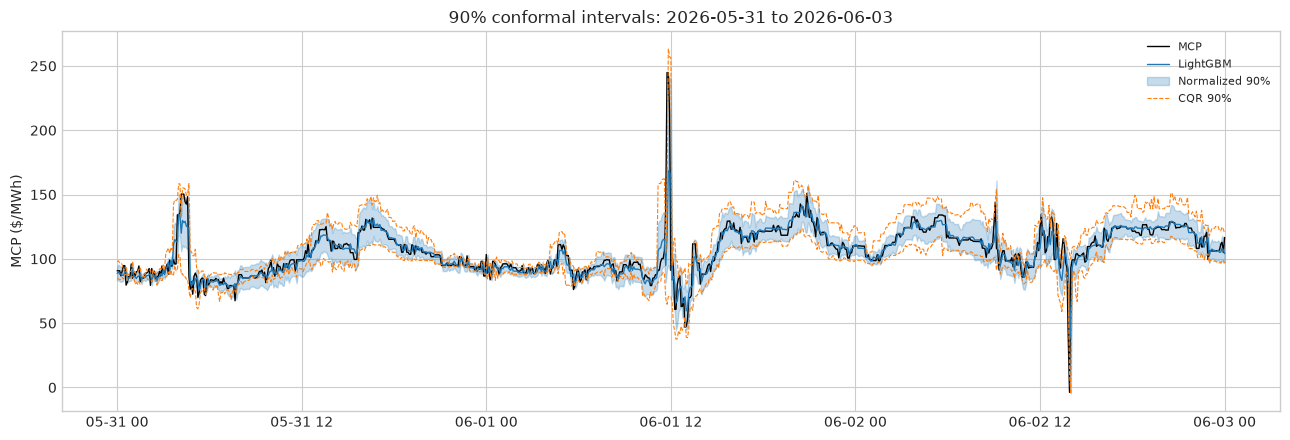

In [13]:
# A few days of 90% intervals around a high-volatility week if present, else the first test week.
sample_start = predictions.index.min()
# Prefer a mid-test week so the plot is not the split boundary.
mid = predictions.index[len(predictions) // 2]
sample_start = mid.normalize()
sample = predictions.loc[sample_start : sample_start + pd.Timedelta(days=3)]
if len(sample) < 100:
    sample = predictions.iloc[: 3 * 288]

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(sample.index, sample["actual"], color="black", lw=1.0, label="MCP")
ax.plot(sample.index, sample["lightgbm"], color="C0", lw=1.0, label="LightGBM")
ax.fill_between(
    sample.index,
    sample["norm_lower_90"],
    sample["norm_upper_90"],
    color="C0",
    alpha=0.25,
    label="Normalized 90%",
)
if "cqr_lower_90" in sample.columns:
    ax.plot(sample.index, sample["cqr_lower_90"], color="C1", ls="--", lw=0.8, label="CQR 90%")
    ax.plot(sample.index, sample["cqr_upper_90"], color="C1", ls="--", lw=0.8)
ax.set_ylabel("MCP ($/MWh)")
ax.set_title(f"90% conformal intervals: {sample.index.min().date()} to {sample.index.max().date()}")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "cps_interval_sample.png", dpi=150, bbox_inches="tight")
plt.show()


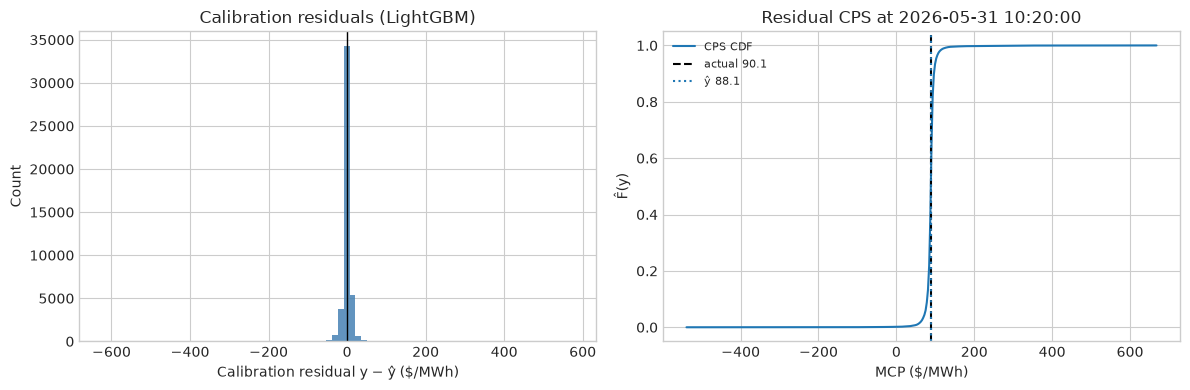

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(resid_cal, bins=80, color="steelblue", alpha=0.85)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Calibration residual y − ŷ ($/MWh)")
ax.set_ylabel("Count")
ax.set_title("Calibration residuals (LightGBM)")

ax = axes[1]
example_idx = len(predictions) // 2
yhat_ex = float(predictions["lightgbm"].iloc[example_idx])
actual_ex = float(predictions["actual"].iloc[example_idx])
grid = np.linspace(
    yhat_ex + resid_sorted[0] - 5,
    yhat_ex + resid_sorted[-1] + 5,
    400,
)
# Residual CPS CDF: (#{R_i <= y - ŷ} + 1) / (n+1)
cdf = (np.searchsorted(resid_sorted, grid - yhat_ex, side="right") + 1) / (n_cal + 1)
ax.plot(grid, cdf, color="C0", label="CPS CDF")
ax.axvline(actual_ex, color="black", ls="--", label=f"actual {actual_ex:.1f}")
ax.axvline(yhat_ex, color="C0", ls=":", label=f"ŷ {yhat_ex:.1f}")
ax.set_xlabel("MCP ($/MWh)")
ax.set_ylabel("F̂(y)")
ax.set_title(f"Residual CPS at {predictions.index[example_idx]}")
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "cps_residual_and_cdf.png", dpi=150, bbox_inches="tight")
plt.show()


In [15]:
predictions.to_csv(RESULTS_DIR / "cps_test_forecasts.csv")
point_results.to_csv(RESULTS_DIR / "cps_point_scores.csv")
interval_results.to_csv(RESULTS_DIR / "cps_interval_scores.csv", index=False)
monthly_coverage.to_csv(RESULTS_DIR / "cps_monthly_coverage.csv", index=False)
pinball_results.to_csv(RESULTS_DIR / "cps_pinball.csv", index=False)
pd.Series({"mean_crps": float(cps_crps.mean()), "median_crps": float(np.median(cps_crps))}).to_csv(
    RESULTS_DIR / "cps_crps.csv"
)
print(f"Saved forecast outputs and figures to {RESULTS_DIR}")
print("Figures:", sorted(p.name for p in FIGURE_DIR.glob("cps_*.png")))


Saved forecast outputs and figures to /app/reports/forecasting
Figures: ['cps_coverage_diagnostics.png', 'cps_interval_sample.png', 'cps_residual_and_cdf.png']


## What to read from the tables

- **Coverage gap** near zero means the interval is calibrated at that nominal level. A large negative gap on the 50% interval is common for symmetric split conformal on spiked prices: the absolute-residual quantile is dominated by the tails, so the centre of the distribution is under-covered.
- **Normalized split** and **CQR** should have similar coverage but **narrower mean width** if the scale/quantile models pick up diurnal and spike heteroscedasticity.
- **Monthly and hourly coverage** are the honest check. Exchangeability fails across seasons and evening ramps; those plots show where a later rolling-calibration or EnbPI scheme is needed.
- **CRPS and pinball** score the residual CPS as a full predictive distribution, which is the object that will later be compared with quantile regression averaging.

## Next implementation steps

1. Freeze the train / calibration / test calendar dates in the thesis methodology (replace the 70/15/15 proportions).
2. Confirm publication times for STEM, RTP, and operational demand against AEMO release schedules; drop any series that is not available at $t-5$.
3. Add a rolling or adaptive calibration window (ACI / EnbPI) and report coverage under that weaker assumption.
4. Implement QRA on the same LightGBM point forecasts and the same test origins, then compare CRPS, pinball, Winkler, and a directional trading loss.
5. Split spike vs non-spike regimes (for example MCP above the training 99th percentile) and report coverage and width in each.
